# 異常ピクセル検出 notebook

anomaly_pixel_detector.py

## Purpose
Detect band-specific anomalous pixels in hyperspectral ROI spectra.
This is designed for cases where pixels arranged in diagonal/line-like patterns
show abnormally high values at one or a few wavelengths.

## Input CSV format
The CSV is expected to contain:
    y, x, wave_XXXX.XXnm, wave_XXXX.XXnm, ...

## Typical usage
1. Edit the CONFIG section below.
2. Run this file as a separate Python script or execute cells in Jupyter.

## Outputs
- anomaly_pixel_summary.csv
- anomaly_mask.csv
- max_positive_z_map.csv
- max_positive_z_map.png
- anomaly_mask.png
- anomaly_wavelength_map.png
- x-slice spectra/z-score CSV and PNG files for selected x values

## 使い方
1. CONFIGセルの `CSV_PATH`, `OUT_DIR`, `WL_MIN`, `WL_MAX` を確認してください。
2. 上から順に実行してください。
3. 最後の `main()` セルを実行すると、検出・CSV保存・図保存まで行います。

In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

In [ ]:
# ============================================================
# CONFIG: edit here

In [2]:
# ============================================================

CSV_PATH = r"D:\research\code\all_roi_spectra200x200.csv"
OUT_DIR = r"D:\research\code\anomaly_pixel_check"

# Wavelength range currently used for MF.
WL_MIN = 2100.0
WL_MAX = 2450.0
EXCLUDE_RANGES: Optional[Sequence[Tuple[float, float]]] = None

# Local neighborhood size for spatial anomaly detection.
# Must be odd. Try 9, 11, 15, 21 depending on line width.
LOCAL_WINDOW_SIZE = 11

# Robust z-score threshold for anomalous band values.
# If too many pixels are detected, increase to 7 or 8.
# If too few pixels are detected, decrease to 4 or 5.
Z_THRESHOLD = 6.0

# Band-specific spike condition.
# If not None, only pixels with <= this number of high-z bands are kept.
# This is useful for detecting "one-band spike" anomalies.
# Set to None if you do not want this condition.
MAX_HIGH_BANDS = 3

# Positive anomaly means pixel spectrum is larger than local surroundings.
# If False, both positive and negative anomalies are detected using abs(z).
POSITIVE_ONLY = True

# Export and plot y-wavelength heatmaps for these x values.
# These x values are interpreted as CSV x coordinates if possible.
X_VALUES_TO_CHECK = [10]

# Optional: inspect specific pixels, interpreted as CSV coordinates if possible.
PIXELS_TO_PLOT = [
    # (y, x),
]

In [ ]:
# ============================================================
# Loading and cube construction
# ============================================================

def get_wave_columns(df: pd.DataFrame) -> tuple[list[str], np.ndarray]:
    """Find columns like wave_2300.00nm and return them sorted by wavelength."""
    wave_cols: list[str] = []
    wavelengths: list[float] = []
    pattern = re.compile(r"^wave_([0-9]+(?:\.[0-9]+)?)nm$")

    for col in df.columns:
        m = pattern.match(str(col))
        if m is not None:
            wave_cols.append(col)
            wavelengths.append(float(m.group(1)))

    if len(wave_cols) == 0:
        raise ValueError("No wavelength columns found. Expected columns like wave_2300.00nm.")

    wavelengths_arr = np.asarray(wavelengths, dtype=float)
    order = np.argsort(wavelengths_arr)
    wavelengths_arr = wavelengths_arr[order]
    wave_cols = [wave_cols[i] for i in order]

    return wave_cols, wavelengths_arr


def load_roi_spectra_csv(path: str | Path) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, list[str]]:
    """Load ROI spectra CSV."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"CSV not found: {path}")

    df = pd.read_csv(path)

    if "y" not in df.columns or "x" not in df.columns:
        raise ValueError("The CSV must contain 'y' and 'x' columns.")

    wave_cols, wavelengths = get_wave_columns(df)
    spectra = df[wave_cols].to_numpy(dtype=float)

    return df, wavelengths, spectra, wave_cols


def spectra_to_cube(
    df: pd.DataFrame,
    spectra: np.ndarray,
    fill_value: float = np.nan,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert table spectra to cube[H, W, B].

    cube row/col indices are sorted unique y/x coordinates.
    Returns:
        cube, ys, xs
    where ys[row] = original CSV y coordinate, xs[col] = original CSV x coordinate.
    """
    ys = np.sort(df["y"].unique())
    xs = np.sort(df["x"].unique())

    y_to_row = {y: i for i, y in enumerate(ys)}
    x_to_col = {x: j for j, x in enumerate(xs)}

    H, W = len(ys), len(xs)
    B = spectra.shape[1]
    cube = np.full((H, W, B), fill_value, dtype=float)

    for row_idx, row in df.iterrows():
        i = y_to_row[row["y"]]
        j = x_to_col[row["x"]]
        cube[i, j, :] = spectra[row_idx, :]

    return cube, ys, xs


def band_mask(
    wavelengths: np.ndarray,
    wl_min: Optional[float] = None,
    wl_max: Optional[float] = None,
    exclude_ranges: Optional[Sequence[Tuple[float, float]]] = None,
) -> np.ndarray:
    """Create wavelength selection mask."""
    mask = np.ones_like(wavelengths, dtype=bool)

    if wl_min is not None:
        mask &= wavelengths >= wl_min
    if wl_max is not None:
        mask &= wavelengths <= wl_max
    if exclude_ranges is not None:
        for a, b in exclude_ranges:
            mask &= ~((wavelengths >= a) & (wavelengths <= b))

    return mask


def make_valid_mask(cube: np.ndarray, require_positive: bool = True) -> np.ndarray:
    """Valid if all selected-band values are finite and optionally positive."""
    valid = np.all(np.isfinite(cube), axis=2)
    if require_positive:
        valid &= np.all(cube > 0, axis=2)
    return valid


def resolve_x_to_col(xs: np.ndarray, x_value: int | float) -> int:
    """
    Convert CSV x coordinate to cube col index.
    If x_value is not in xs, use it as a col index.
    """
    matches = np.where(xs == x_value)[0]
    if len(matches) > 0:
        return int(matches[0])

    col = int(x_value)
    if not (0 <= col < len(xs)):
        raise ValueError(f"x={x_value} was not found as CSV x and is not a valid col index.")
    return col


def resolve_yx_to_row_col(ys: np.ndarray, xs: np.ndarray, y_value: int | float, x_value: int | float) -> tuple[int, int]:
    """
    Convert CSV y/x coordinates to cube row/col indices.
    If not found, interpret as row/col indices.
    """
    y_matches = np.where(ys == y_value)[0]
    x_matches = np.where(xs == x_value)[0]

    if len(y_matches) > 0:
        row = int(y_matches[0])
    else:
        row = int(y_value)

    if len(x_matches) > 0:
        col = int(x_matches[0])
    else:
        col = int(x_value)

    if not (0 <= row < len(ys) and 0 <= col < len(xs)):
        raise ValueError(f"(y, x)=({y_value}, {x_value}) is outside cube shape.")

    return row, col

In [ ]:
# ============================================================
# Band-specific local anomaly detection
# ============================================================

def _median_filter_ignore_invalid_2d(
    image: np.ndarray,
    valid_mask: np.ndarray,
    size: int,
) -> np.ndarray:
    """
    Fast approximate median filter with invalid pixels filled by global median.
    Suitable when invalid pixels are rare.
    """
    img = image.astype(float).copy()
    finite_valid = valid_mask & np.isfinite(img)

    if np.any(finite_valid):
        fill = np.nanmedian(img[finite_valid])
    else:
        fill = 0.0

    img[~finite_valid] = fill
    return median_filter(img, size=size, mode="reflect")


def compute_local_robust_zcube(
    cube: np.ndarray,
    valid_mask: np.ndarray,
    window_size: int = 11,
    eps: float = 1e-12,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute local robust z-score for each band.

    For each band:
        local_median = median_filter(band)
        local_mad    = median_filter(abs(band - local_median))
        robust_std   = 1.4826 * local_mad
        z            = (band - local_median) / robust_std

    Returns:
        zcube, local_median_cube, local_robust_std_cube
    """
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd.")

    H, W, B = cube.shape
    zcube = np.full_like(cube, np.nan, dtype=float)
    local_med_cube = np.full_like(cube, np.nan, dtype=float)
    local_rstd_cube = np.full_like(cube, np.nan, dtype=float)

    print(f"Computing local robust z-score: H={H}, W={W}, B={B}, window={window_size}")

    for b in range(B):
        band = cube[:, :, b]
        local_med = _median_filter_ignore_invalid_2d(band, valid_mask, size=window_size)
        abs_dev = np.abs(band - local_med)
        local_mad = _median_filter_ignore_invalid_2d(abs_dev, valid_mask, size=window_size)
        local_rstd = 1.4826 * local_mad + eps

        z = (band - local_med) / local_rstd
        z[~valid_mask] = np.nan

        zcube[:, :, b] = z
        local_med_cube[:, :, b] = local_med
        local_rstd_cube[:, :, b] = local_rstd

        if (b + 1) % max(1, B // 10) == 0 or b == B - 1:
            print(f"  band {b + 1}/{B} done")

    return zcube, local_med_cube, local_rstd_cube


def detect_band_spike_anomalies(
    cube: np.ndarray,
    wavelengths: np.ndarray,
    valid_mask: np.ndarray,
    ys: np.ndarray,
    xs: np.ndarray,
    zcube: np.ndarray,
    local_med_cube: np.ndarray,
    local_rstd_cube: np.ndarray,
    z_threshold: float = 6.0,
    max_high_bands: Optional[int] = 3,
    positive_only: bool = True,
) -> tuple[pd.DataFrame, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Detect pixels whose spectrum has one or a few locally anomalous bands.

    Returns:
        df_anom, anomaly_mask, score_map, argband_map, n_high_band_map
    """
    H, W, B = cube.shape

    if positive_only:
        score_cube = zcube.copy()
        high_cube = zcube >= z_threshold
        score_map = np.nanmax(score_cube, axis=2)
        argband_map = np.nanargmax(np.where(np.isfinite(score_cube), score_cube, -np.inf), axis=2)
    else:
        score_cube = np.abs(zcube)
        high_cube = score_cube >= z_threshold
        score_map = np.nanmax(score_cube, axis=2)
        argband_map = np.nanargmax(np.where(np.isfinite(score_cube), score_cube, -np.inf), axis=2)

    n_high_band_map = np.sum(high_cube, axis=2)

    anomaly_mask = valid_mask & np.isfinite(score_map) & (score_map >= z_threshold)

    if max_high_bands is not None:
        anomaly_mask &= n_high_band_map <= max_high_bands

    rows = []
    rr, cc = np.where(anomaly_mask)

    for r, c in zip(rr, cc):
        b = int(argband_map[r, c])
        rows.append({
            "row": int(r),
            "col": int(c),
            "y": ys[r],
            "x": xs[c],
            "max_z": float(score_map[r, c]),
            "signed_z_at_max_band": float(zcube[r, c, b]),
            "max_z_wavelength_nm": float(wavelengths[b]),
            "max_z_band_index": b,
            "n_high_bands": int(n_high_band_map[r, c]),
            "spectrum_value_at_max_band": float(cube[r, c, b]),
            "local_median_at_max_band": float(local_med_cube[r, c, b]),
            "local_robust_std_at_max_band": float(local_rstd_cube[r, c, b]),
            "difference_from_local_median": float(cube[r, c, b] - local_med_cube[r, c, b]),
        })

    df_anom = pd.DataFrame(rows)
    if len(df_anom) > 0:
        df_anom = df_anom.sort_values("max_z", ascending=False).reset_index(drop=True)

    return df_anom, anomaly_mask, score_map, argband_map, n_high_band_map

In [ ]:
# ============================================================
# Export and plotting utilities
# ============================================================

def save_map_csv(arr: np.ndarray, path: str | Path) -> None:
    path = Path(path)
    pd.DataFrame(arr).to_csv(path, index=False, header=False)
    print(f"Saved: {path}")


def plot_map(
    arr: np.ndarray,
    title: str,
    out_png: str | Path,
    colorbar_label: str = "value",
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    cmap: Optional[str] = None,
) -> None:
    plt.figure(figsize=(7, 6))
    im = plt.imshow(arr, origin="upper", vmin=vmin, vmax=vmax, cmap=cmap)
    plt.colorbar(im, label=colorbar_label)
    plt.xlabel("x / col")
    plt.ylabel("y / row")
    plt.title(title)
    plt.tight_layout()
    out_png = Path(out_png)
    plt.savefig(out_png, dpi=200)
    plt.show()
    print(f"Saved: {out_png}")


def plot_anomaly_overlay(
    base_map: np.ndarray,
    anomaly_mask: np.ndarray,
    out_png: str | Path,
    title: str = "Anomaly pixels over max z map",
) -> None:
    finite = base_map[np.isfinite(base_map)]
    if finite.size > 0:
        vmin = np.nanpercentile(finite, 2)
        vmax = np.nanpercentile(finite, 98)
    else:
        vmin, vmax = None, None

    plt.figure(figsize=(7, 6))
    plt.imshow(base_map, origin="upper", vmin=vmin, vmax=vmax)
    yy, xx = np.where(anomaly_mask)
    plt.scatter(xx, yy, s=8, facecolors="none", edgecolors="red", linewidths=0.7, label="anomaly")
    plt.colorbar(label="max positive robust z-score")
    plt.xlabel("x / col")
    plt.ylabel("y / row")
    plt.title(title)
    plt.legend(loc="upper right")
    plt.tight_layout()
    out_png = Path(out_png)
    plt.savefig(out_png, dpi=200)
    plt.show()
    print(f"Saved: {out_png}")


def export_x_slice(
    cube: np.ndarray,
    wavelengths: np.ndarray,
    zcube: np.ndarray,
    ys: np.ndarray,
    xs: np.ndarray,
    x_value: int | float,
    out_dir: str | Path,
    valid_mask: Optional[np.ndarray] = None,
    anomaly_mask: Optional[np.ndarray] = None,
) -> tuple[pd.DataFrame, pd.DataFrame, int]:
    """Export spectra and z-score matrices along a given x coordinate/column."""
    out_dir = Path(out_dir)
    col = resolve_x_to_col(xs, x_value)
    x_coord = xs[col]

    H, W, B = cube.shape
    wave_cols = [f"wave_{wl:.2f}nm" for wl in wavelengths]
    z_cols = [f"z_wave_{wl:.2f}nm" for wl in wavelengths]

    df_spec = pd.DataFrame(cube[:, col, :], columns=wave_cols)
    df_spec.insert(0, "x", x_coord)
    df_spec.insert(0, "y", ys)
    df_spec.insert(0, "col", col)
    df_spec.insert(0, "row", np.arange(H))

    df_z = pd.DataFrame(zcube[:, col, :], columns=z_cols)
    df_z.insert(0, "x", x_coord)
    df_z.insert(0, "y", ys)
    df_z.insert(0, "col", col)
    df_z.insert(0, "row", np.arange(H))

    if valid_mask is not None:
        df_spec["is_valid"] = valid_mask[:, col]
        df_z["is_valid"] = valid_mask[:, col]

    if anomaly_mask is not None:
        df_spec["is_anomaly"] = anomaly_mask[:, col]
        df_z["is_anomaly"] = anomaly_mask[:, col]

    spec_path = out_dir / f"x_{x_coord}_spectra.csv"
    z_path = out_dir / f"x_{x_coord}_zscore.csv"
    df_spec.to_csv(spec_path, index=False)
    df_z.to_csv(z_path, index=False)

    print(f"Saved: {spec_path}")
    print(f"Saved: {z_path}")

    return df_spec, df_z, col


def plot_x_slice_heatmap(
    matrix: np.ndarray,
    wavelengths: np.ndarray,
    x_label: str,
    out_png: str | Path,
    title: str,
    colorbar_label: str,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    cmap: Optional[str] = None,
) -> None:
    H, B = matrix.shape
    plt.figure(figsize=(9, 6))
    im = plt.imshow(
        matrix,
        aspect="auto",
        origin="upper",
        extent=[wavelengths[0], wavelengths[-1], H - 1, 0],
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
    )
    plt.colorbar(im, label=colorbar_label)
    plt.xlabel("Wavelength [nm]")
    plt.ylabel("row")
    plt.title(title + f" ({x_label})")
    plt.tight_layout()
    out_png = Path(out_png)
    plt.savefig(out_png, dpi=200)
    plt.show()
    print(f"Saved: {out_png}")


def plot_pixel_spectrum(
    cube: np.ndarray,
    wavelengths: np.ndarray,
    zcube: np.ndarray,
    ys: np.ndarray,
    xs: np.ndarray,
    y_value: int | float,
    x_value: int | float,
    out_png: str | Path,
) -> None:
    """Plot one pixel spectrum and its local robust z-score."""
    row, col = resolve_yx_to_row_col(ys, xs, y_value, x_value)
    spec = cube[row, col, :]
    z = zcube[row, col, :]

    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

    axes[0].plot(wavelengths, spec, marker="o")
    axes[0].set_ylabel("Radiance / Reflectance")
    axes[0].set_title(f"Spectrum at y={ys[row]}, x={xs[col]}  (row={row}, col={col})")
    axes[0].grid(True)

    axes[1].plot(wavelengths, z, marker="o")
    axes[1].axhline(0, linewidth=1)
    axes[1].axhline(Z_THRESHOLD, linestyle="--", linewidth=1)
    axes[1].set_xlabel("Wavelength [nm]")
    axes[1].set_ylabel("Local robust z-score")
    axes[1].grid(True)

    plt.tight_layout()
    out_png = Path(out_png)
    plt.savefig(out_png, dpi=200)
    plt.show()
    print(f"Saved: {out_png}")

In [ ]:
# ============================================================
# Main workflow
# ============================================================

def main() -> None:
    out_dir = Path(OUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    print("Loading ROI spectra CSV...")
    df, wavelengths_all, spectra_all, wave_cols_all = load_roi_spectra_csv(CSV_PATH)
    cube_all, ys, xs = spectra_to_cube(df, spectra_all)

    print(f"CSV rows: {len(df)}")
    print(f"Cube shape: {cube_all.shape}")
    print(f"Original y range: {ys[0]} to {ys[-1]}")
    print(f"Original x range: {xs[0]} to {xs[-1]}")
    print(f"Wavelength range: {wavelengths_all[0]:.2f} to {wavelengths_all[-1]:.2f} nm")

    print("Selecting MF wavelength range...")
    bmask = band_mask(wavelengths_all, WL_MIN, WL_MAX, EXCLUDE_RANGES)
    cube = cube_all[:, :, bmask]
    wavelengths = wavelengths_all[bmask]

    if cube.shape[2] == 0:
        raise ValueError("No bands selected. Check WL_MIN/WL_MAX/EXCLUDE_RANGES.")

    print(f"Selected bands: {cube.shape[2]}")
    print(f"Selected wavelength range: {wavelengths[0]:.2f} to {wavelengths[-1]:.2f} nm")

    valid_mask = make_valid_mask(cube, require_positive=True)
    print(f"Valid pixels: {np.sum(valid_mask)} / {valid_mask.size}")

    zcube, local_med_cube, local_rstd_cube = compute_local_robust_zcube(
        cube=cube,
        valid_mask=valid_mask,
        window_size=LOCAL_WINDOW_SIZE,
    )

    df_anom, anomaly_mask, score_map, argband_map, n_high_band_map = detect_band_spike_anomalies(
        cube=cube,
        wavelengths=wavelengths,
        valid_mask=valid_mask,
        ys=ys,
        xs=xs,
        zcube=zcube,
        local_med_cube=local_med_cube,
        local_rstd_cube=local_rstd_cube,
        z_threshold=Z_THRESHOLD,
        max_high_bands=MAX_HIGH_BANDS,
        positive_only=POSITIVE_ONLY,
    )

    print(f"Detected anomaly pixels: {len(df_anom)}")

    # Save tables and maps
    df_anom.to_csv(out_dir / "anomaly_pixel_summary.csv", index=False)
    print(f"Saved: {out_dir / 'anomaly_pixel_summary.csv'}")

    save_map_csv(anomaly_mask.astype(int), out_dir / "anomaly_mask.csv")
    save_map_csv(score_map, out_dir / "max_positive_z_map.csv")
    save_map_csv(n_high_band_map, out_dir / "n_high_band_map.csv")

    # Wavelength map: each pixel stores wavelength where max score occurred
    wavelength_map = np.full(score_map.shape, np.nan, dtype=float)
    finite_score = np.isfinite(score_map)
    wavelength_map[finite_score] = wavelengths[argband_map[finite_score]]
    save_map_csv(wavelength_map, out_dir / "max_z_wavelength_map.csv")

    # Figures
    finite = score_map[np.isfinite(score_map)]
    vmax = np.nanpercentile(finite, 99) if finite.size > 0 else None

    plot_map(
        score_map,
        title="Maximum positive local robust z-score",
        out_png=out_dir / "max_positive_z_map.png",
        colorbar_label="max positive robust z-score",
        vmin=0,
        vmax=vmax,
    )

    plot_map(
        anomaly_mask.astype(float),
        title=f"Band-specific anomaly mask, z >= {Z_THRESHOLD}",
        out_png=out_dir / "anomaly_mask.png",
        colorbar_label="anomaly",
        vmin=0,
        vmax=1,
    )

    plot_map(
        wavelength_map,
        title="Wavelength of maximum local z-score",
        out_png=out_dir / "anomaly_wavelength_map.png",
        colorbar_label="wavelength [nm]",
    )

    plot_anomaly_overlay(
        base_map=score_map,
        anomaly_mask=anomaly_mask,
        out_png=out_dir / "anomaly_overlay.png",
    )

    # Export and plot selected x slices
    for x_value in X_VALUES_TO_CHECK:
        df_spec, df_z, col = export_x_slice(
            cube=cube,
            wavelengths=wavelengths,
            zcube=zcube,
            ys=ys,
            xs=xs,
            x_value=x_value,
            out_dir=out_dir,
            valid_mask=valid_mask,
            anomaly_mask=anomaly_mask,
        )
        x_coord = xs[col]

        plot_x_slice_heatmap(
            matrix=cube[:, col, :],
            wavelengths=wavelengths,
            x_label=f"x={x_coord}, col={col}",
            out_png=out_dir / f"x_{x_coord}_spectra_heatmap.png",
            title="Spectra along x-slice",
            colorbar_label="Radiance / Reflectance",
        )

        plot_x_slice_heatmap(
            matrix=zcube[:, col, :],
            wavelengths=wavelengths,
            x_label=f"x={x_coord}, col={col}",
            out_png=out_dir / f"x_{x_coord}_zscore_heatmap.png",
            title="Local robust z-score along x-slice",
            colorbar_label="local robust z-score",
            vmin=-Z_THRESHOLD,
            vmax=Z_THRESHOLD,
        )

    # Plot selected pixels if requested
    for y_value, x_value in PIXELS_TO_PLOT:
        safe_name = f"pixel_y{y_value}_x{x_value}_spectrum.png".replace(".", "p")
        plot_pixel_spectrum(
            cube=cube,
            wavelengths=wavelengths,
            zcube=zcube,
            ys=ys,
            xs=xs,
            y_value=y_value,
            x_value=x_value,
            out_png=out_dir / safe_name,
        )

    print("Done.")
    print(f"Output directory: {out_dir}")

## 実行

以下を実行すると、異常ピクセル検出、CSV保存、図の保存までまとめて行います。

Loading ROI spectra CSV...
CSV rows: 40000
Cube shape: (200, 200, 185)
Original y range: 0 to 199
Original x range: 0 to 199
Wavelength range: 405.00 to 2474.76 nm
Selecting MF wavelength range...
Selected bands: 29
Selected wavelength range: 2100.05 to 2449.78 nm
Valid pixels: 40000 / 40000
Computing local robust z-score: H=200, W=200, B=29, window=11
  band 2/29 done
  band 4/29 done
  band 6/29 done
  band 8/29 done
  band 10/29 done
  band 12/29 done
  band 14/29 done
  band 16/29 done
  band 18/29 done
  band 20/29 done
  band 22/29 done
  band 24/29 done
  band 26/29 done
  band 28/29 done
  band 29/29 done
Detected anomaly pixels: 218
Saved: D:\research\code\anomaly_pixel_check\anomaly_pixel_summary.csv
Saved: D:\research\code\anomaly_pixel_check\anomaly_mask.csv
Saved: D:\research\code\anomaly_pixel_check\max_positive_z_map.csv
Saved: D:\research\code\anomaly_pixel_check\n_high_band_map.csv
Saved: D:\research\code\anomaly_pixel_check\max_z_wavelength_map.csv


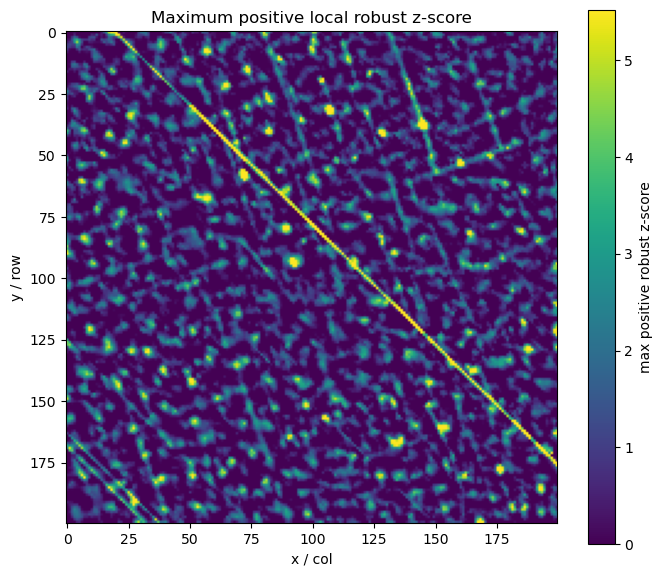

Saved: D:\research\code\anomaly_pixel_check\max_positive_z_map.png


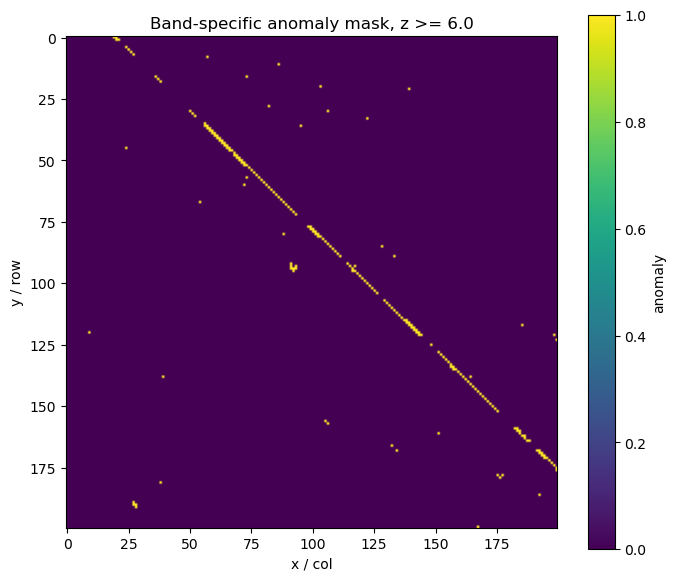

Saved: D:\research\code\anomaly_pixel_check\anomaly_mask.png


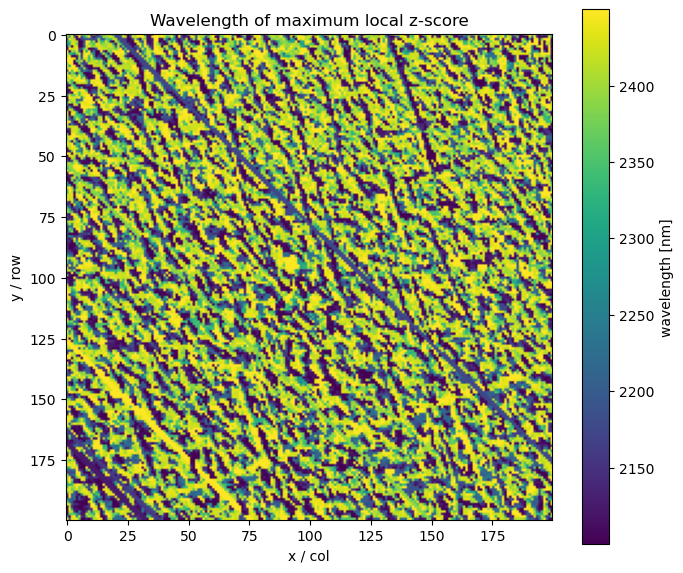

Saved: D:\research\code\anomaly_pixel_check\anomaly_wavelength_map.png


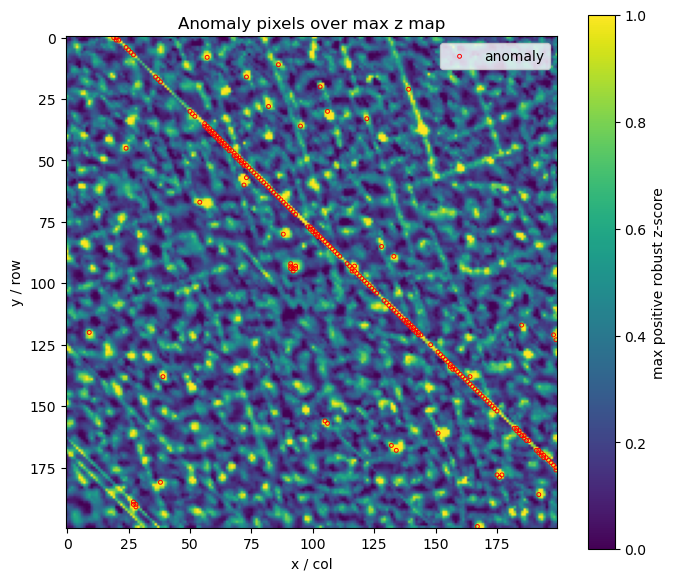

Saved: D:\research\code\anomaly_pixel_check\anomaly_overlay.png
Saved: D:\research\code\anomaly_pixel_check\x_10_spectra.csv
Saved: D:\research\code\anomaly_pixel_check\x_10_zscore.csv


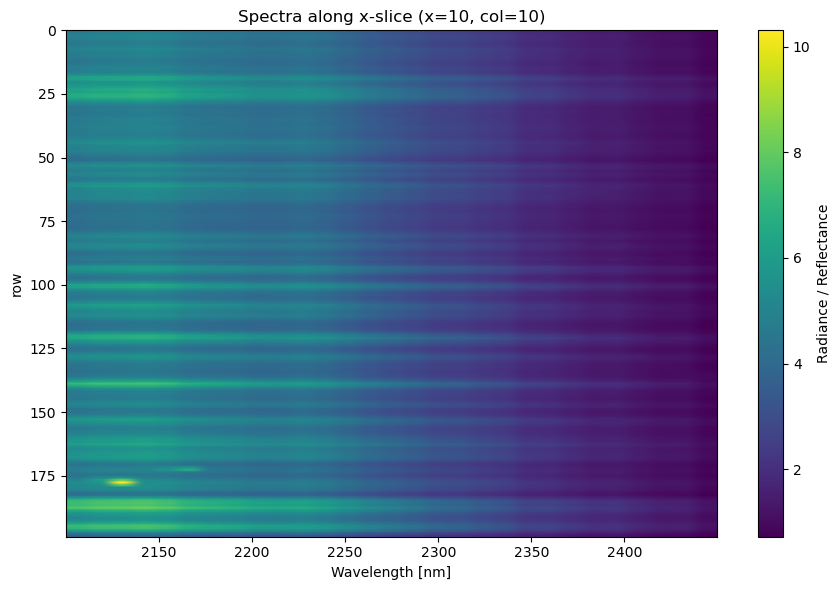

Saved: D:\research\code\anomaly_pixel_check\x_10_spectra_heatmap.png


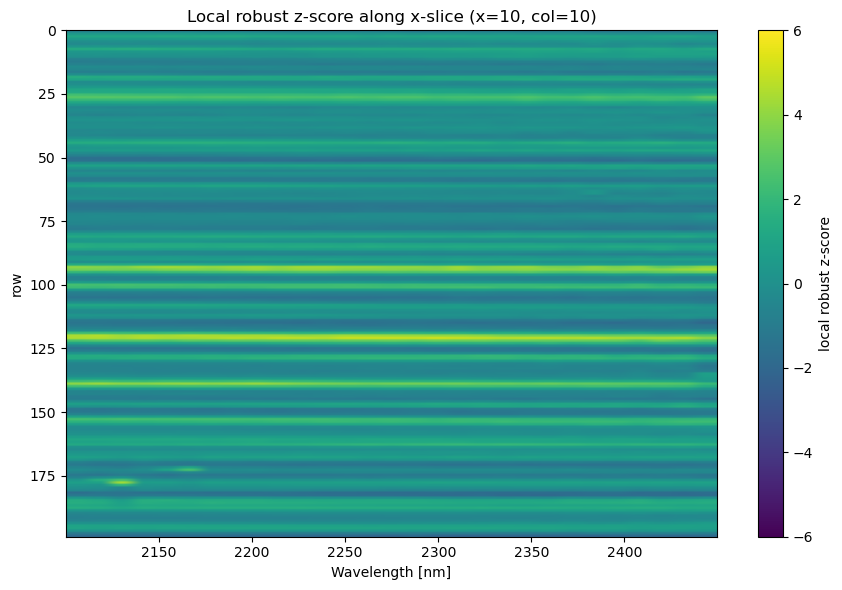

Saved: D:\research\code\anomaly_pixel_check\x_10_zscore_heatmap.png
Done.
Output directory: D:\research\code\anomaly_pixel_check


In [7]:
main()

In [8]:
def plot_spectra_at_fixed_x(cube, wavelengths, x, y_range=None, valid_mask=None,
                            alpha=0.35, linewidth=0.8, title=None, xlim=None):
    """
    固定した x に対して、複数の y ピクセルのスペクトルを重ね描きする。

    Parameters
    ----------
    cube : ndarray, shape = (H, W, B)
        ハイパースペクトルcube
    wavelengths : ndarray, shape = (B,)
        波長配列
    x : int
        固定する x 座標（列番号）
    y_range : iterable or None
        描画する y の範囲。Noneなら全yを使う
    valid_mask : ndarray or None, shape = (H, W)
        有効画素だけ描きたいときに使う
    alpha : float
        線の透明度
    linewidth : float
        線の太さ
    title : str or None
        グラフタイトル
    xlim : tuple or None
        波長軸の範囲
    """

    H, W, B = cube.shape

    if not (0 <= x < W):
        raise ValueError(f"x={x} is outside image width W={W}")

    if y_range is None:
        y_range = range(H)

    plt.figure(figsize=(10, 6))

    count = 0
    for y in y_range:
        if not (0 <= y < H):
            continue

        if valid_mask is not None:
            if not valid_mask[y, x]:
                continue

        spec = cube[y, x, :]
        plt.plot(wavelengths, spec, alpha=alpha, linewidth=linewidth)
        count += 1

    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Radiance")
    
    if title is None:
        title = f"Spectra at x={x} (n={count})"
    plt.title(title)

    if xlim is not None:
        plt.xlim(*xlim)

    plt.grid(True)
    plt.show()

In [9]:
plot_spectra_at_fixed_x(
    cube=cube_2300,
    wavelengths=wave_2300,
    x=10,
    y_range=range(cube_2300.shape[0]),   # 全y
    valid_mask=valid_mask_2300,
    xlim=(2100, 2450),
    title="Spectra at x=10"
)

NameError: name 'cube_2300' is not defined

In [10]:
def get_wave_columns_from_csv(df):
    """
    CSV内の wave_****nm 形式の列を探して、波長順に並べる。
    """

    wave_cols = []
    wavelengths = []

    for col in df.columns:
        if col.startswith("wave_"):
            wl_str = col.replace("wave_", "").replace("nm", "")
            try:
                wl = float(wl_str)
                wave_cols.append(col)
                wavelengths.append(wl)
            except ValueError:
                pass

    wavelengths = np.array(wavelengths)

    order = np.argsort(wavelengths)
    wavelengths = wavelengths[order]
    wave_cols = [wave_cols[i] for i in order]

    return wave_cols, wavelengths

In [11]:
def plot_spectra_from_csv_fixed_x(
    csv_path,
    x_value,
    y_min=0,
    y_max=200,
    wl_min=2100.0,
    wl_max=2450.0,
    alpha=0.35,
    linewidth=0.8,
    save_fig=None
):
    """
    all_roi_spectra200x200.csv から、
    x = x_value かつ y_min <= y <= y_max のピクセルスペクトルを重ね描きする。

    横軸: 波長
    縦軸: 放射輝度 / 反射率
    """

    df = pd.read_csv(csv_path)

    wave_cols, wavelengths = get_wave_columns_from_csv(df)

    # MFで使っている波長帯だけ抜き出す
    band_mask = (wavelengths >= wl_min) & (wavelengths <= wl_max)

    wavelengths_sel = wavelengths[band_mask]
    wave_cols_sel = [c for c, m in zip(wave_cols, band_mask) if m]

    # x, yで対象ピクセルを抽出
    df_sel = df[
        (np.isclose(df["x"], x_value)) &
        (df["y"] >= y_min) &
        (df["y"] <= y_max)
    ].copy()

    df_sel = df_sel.sort_values("y")

    if len(df_sel) == 0:
        raise ValueError(
            f"No pixels found for x={x_value}, y={y_min}..{y_max}. "
            "CSV内のx,y座標を確認してください。"
        )

    spectra = df_sel[wave_cols_sel].to_numpy(dtype=float)
    ys = df_sel["y"].to_numpy()

    plt.figure(figsize=(10, 6))

    for i in range(spectra.shape[0]):
        plt.plot(
            wavelengths_sel,
            spectra[i],
            alpha=alpha,
            linewidth=linewidth
        )

    plt.xlabel("Wavelength [nm]")
    plt.ylabel("Radiance / Reflectance")
    plt.title(f"Spectra at x={x_value}, y={y_min}..{y_max}  (n={len(df_sel)})")
    plt.grid(True)

    if save_fig is not None:
        plt.savefig(save_fig, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {save_fig}")

    plt.show()

    return df_sel, wavelengths_sel, spectra

Saved figure: spectra_x10_y0_200.png


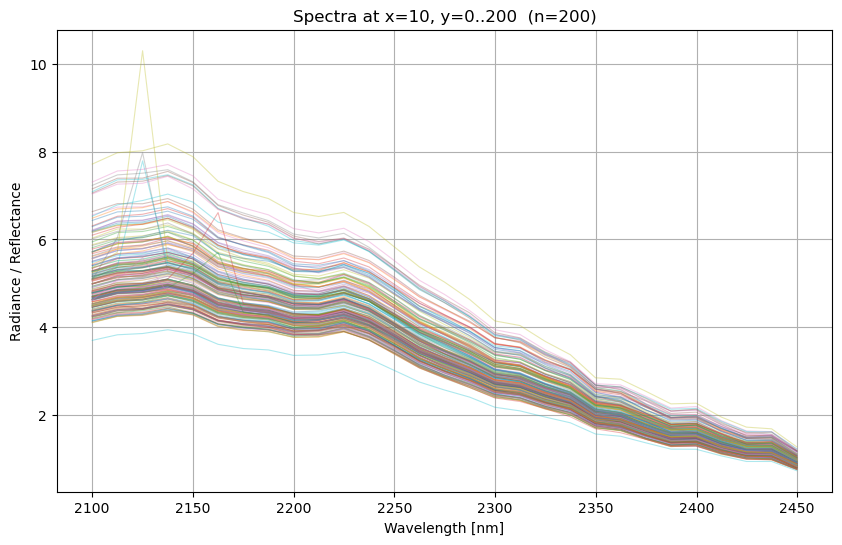

In [ ]:
df_x10, wave_used, spectra_x10 = plot_spectra_from_csv_fixed_x(
    csv_path=CSV_PATH,
    x_value=10,
    y_min=0,
    y_max=200,
    wl_min=WL_MIN,
    wl_max=WL_MAX,
    alpha=0.35,
    linewidth=0.8,
    save_fig="spectra_x10_y0_200.png"
) # detect anomal pixel

In [13]:
def find_spike_y_pixels(df_sel, wavelengths, spectra, z_threshold=5.0, positive_only=True):
    """
    固定x上の複数スペクトルから、特定波長で飛び出しているy座標を探す。

    Parameters
    ----------
    df_sel : DataFrame
        plot_spectra_from_csv_fixed_x() が返した df_x10 など。
        y列を含む。

    wavelengths : ndarray
        使用波長。例: wave_used

    spectra : ndarray, shape=(N_pixels, N_bands)
        各yのスペクトル。例: spectra_x10

    z_threshold : float
        異常判定のしきい値。

    positive_only : bool
        Trueなら「周囲より大きい」スパイクだけ検出。
        Falseなら大きい/小さい両方の外れを検出。

    Returns
    -------
    df_spikes : DataFrame
        飛び出し候補のy座標一覧。
    z : ndarray
        robust z-score配列。
    """

    # 波長ごとに、y方向の中央値とMADを計算
    med = np.nanmedian(spectra, axis=0)
    mad = np.nanmedian(np.abs(spectra - med), axis=0)
    robust_std = 1.4826 * mad + 1e-12

    z = (spectra - med) / robust_std

    rows = []

    ys = df_sel["y"].to_numpy()
    xs = df_sel["x"].to_numpy()

    for i in range(spectra.shape[0]):
        z_i = z[i, :]

        if positive_only:
            idx = np.nanargmax(z_i)
            score = z_i[idx]

            if score >= z_threshold:
                rows.append({
                    "y": ys[i],
                    "x": xs[i],
                    "max_z": score,
                    "wavelength_nm": wavelengths[idx],
                    "spectrum_value": spectra[i, idx],
                    "median_at_wavelength": med[idx],
                    "difference_from_median": spectra[i, idx] - med[idx],
                })

        else:
            idx = np.nanargmax(np.abs(z_i))
            score = z_i[idx]

            if np.abs(score) >= z_threshold:
                rows.append({
                    "y": ys[i],
                    "x": xs[i],
                    "max_abs_z_signed": score,
                    "abs_z": abs(score),
                    "wavelength_nm": wavelengths[idx],
                    "spectrum_value": spectra[i, idx],
                    "median_at_wavelength": med[idx],
                    "difference_from_median": spectra[i, idx] - med[idx],
                })

    df_spikes = pd.DataFrame(rows)

    if len(df_spikes) > 0:
        if positive_only:
            df_spikes = df_spikes.sort_values("max_z", ascending=False)
        else:
            df_spikes = df_spikes.sort_values("abs_z", ascending=False)

    return df_spikes, z

In [18]:
df_spikes_x10, z_x10 = find_spike_y_pixels(
    df_sel=df_x10,
    wavelengths=wave_used,
    spectra=spectra_x10,
    z_threshold=7.0,
    positive_only=True
)

display(df_spikes_x10)

,y,x,max_z,wavelength_nm,spectrum_value,median_at_wavelength,difference_from_median
0,178,10,9.261706,2125.03,10.3104,4.9936,5.3168


In [19]:
target_wavelength = 2162.51

# 2162.51 nm に一番近いバンドを探す
band_idx = np.argmin(np.abs(wave_used - target_wavelength))
actual_wavelength = wave_used[band_idx]

print("Target wavelength:", target_wavelength)
print("Nearest wavelength in data:", actual_wavelength)
print("Band index:", band_idx)

Target wavelength: 2162.51
Nearest wavelength in data: 2162.51
Band index: 5


In [20]:
# x=10 上の各 y における 2162.51 nm 付近の値
values = spectra_x10[:, band_idx]

# y座標
ys = df_x10["y"].to_numpy()
xs = df_x10["x"].to_numpy()

# robust z-score を計算
med = np.nanmedian(values)
mad = np.nanmedian(np.abs(values - med))
robust_std = 1.4826 * mad + 1e-12

z = (values - med) / robust_std

df_2162 = pd.DataFrame({
    "y": ys,
    "x": xs,
    "wavelength_nm": actual_wavelength,
    "spectrum_value": values,
    "median_at_wavelength": med,
    "difference_from_median": values - med,
    "robust_z": z,
})

# z-score が大きい順に並べる
df_2162_sorted = df_2162.sort_values("robust_z", ascending=False)

display(df_2162_sorted.head(20))

,y,x,wavelength_nm,spectrum_value,median_at_wavelength,difference_from_median,robust_z
188,188,10,2162.51,7.3280,4.6544,2.6736,5.123064
186,186,10,2162.51,6.9184,4.6544,2.2640,4.338202
187,187,10,2162.51,6.7936,4.6544,2.1392,4.099064
195,195,10,2162.51,6.7776,4.6544,2.1232,4.068406
139,139,10,2162.51,6.7104,4.6544,2.0560,3.939639
185,185,10,2162.51,6.6976,4.6544,2.0432,3.915112
196,196,10,2162.51,6.6816,4.6544,2.0272,3.884454
173,173,10,2162.51,6.6144,4.6544,1.9600,3.755687
189,189,10,2162.51,6.3968,4.6544,1.7424,3.338729
25,25,10,2162.51,6.2208,4.6544,1.5664,3.001484


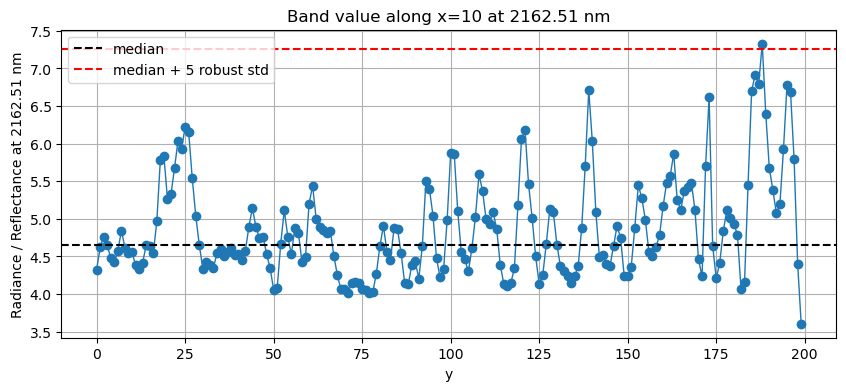

In [21]:
plt.figure(figsize=(10, 4))

plt.plot(ys, values, marker="o", linewidth=1)
plt.axhline(med, color="black", linestyle="--", label="median")
plt.axhline(med + 5.0 * robust_std, color="red", linestyle="--", label="median + 5 robust std")

plt.xlabel("y")
plt.ylabel(f"Radiance / Reflectance at {actual_wavelength:.2f} nm")
plt.title(f"Band value along x=10 at {actual_wavelength:.2f} nm")
plt.grid(True)
plt.legend()
plt.show()

In [22]:
def get_wave_columns_from_csv(df):
    wave_cols = []
    wavelengths = []

    for col in df.columns:
        if col.startswith("wave_"):
            wl_str = col.replace("wave_", "").replace("nm", "")
            try:
                wl = float(wl_str)
                wave_cols.append(col)
                wavelengths.append(wl)
            except ValueError:
                pass

    wavelengths = np.array(wavelengths)

    order = np.argsort(wavelengths)
    wavelengths = wavelengths[order]
    wave_cols = [wave_cols[i] for i in order]

    return wave_cols, wavelengths

In [23]:
def load_fixed_x_spectra_from_csv(
    csv_path,
    x_value,
    y_min=0,
    y_max=200,
    wl_min=2100.0,
    wl_max=2450.0
):
    df = pd.read_csv(csv_path)

    wave_cols, wavelengths = get_wave_columns_from_csv(df)

    band_mask = (wavelengths >= wl_min) & (wavelengths <= wl_max)

    wave_used = wavelengths[band_mask]
    wave_cols_used = [c for c, m in zip(wave_cols, band_mask) if m]

    df_sel = df[
        (np.isclose(df["x"], x_value)) &
        (df["y"] >= y_min) &
        (df["y"] <= y_max)
    ].copy()

    df_sel = df_sel.sort_values("y")

    if len(df_sel) == 0:
        raise ValueError(f"No pixels found for x={x_value}, y={y_min}..{y_max}")

    spectra = df_sel[wave_cols_used].to_numpy(dtype=float)

    return df_sel, wave_used, spectra

In [24]:
df_x10, wave_used, spectra_x10 = load_fixed_x_spectra_from_csv(
    csv_path=CSV_PATH,
    x_value=10,
    y_min=0,
    y_max=200,
    wl_min=WL_MIN,
    wl_max=WL_MAX
)

print(df_x10.shape)
print(wave_used[0], wave_used[-1])
print(spectra_x10.shape)

(200, 187)
2100.05 2449.78
(200, 29)


In [25]:
def detect_single_band_spike(
    df_sel,
    wavelengths,
    spectra,
    target_wavelength,
    neighbor_offset=1,
    z_threshold=5.0
):
    """
    指定波長で、前後バンドに比べて値が飛び出しているピクセルを検出する。

    Parameters
    ----------
    df_sel : DataFrame
        y, x を含むDataFrame。例: df_x10

    wavelengths : ndarray
        使用している波長配列。例: wave_used

    spectra : ndarray, shape=(N_pixels, N_bands)
        各ピクセルのスペクトル。例: spectra_x10

    target_wavelength : float
        異常を見たい波長。例: 2162.51

    neighbor_offset : int
        前後何バンドを使うか。
        1なら i-1, i+1 を使う。

    z_threshold : float
        spike height のrobust z-scoreしきい値。

    Returns
    -------
    df_result : DataFrame
        全yについてのスパイク指標

    df_spike : DataFrame
        しきい値を超えた異常候補
    """

    # 指定波長に一番近いバンド
    i = int(np.argmin(np.abs(wavelengths - target_wavelength)))

    left_i = i - neighbor_offset
    right_i = i + neighbor_offset

    if left_i < 0 or right_i >= len(wavelengths):
        raise ValueError("Target wavelength is too close to edge of selected wavelength range.")

    center_wl = wavelengths[i]
    left_wl = wavelengths[left_i]
    right_wl = wavelengths[right_i]

    center = spectra[:, i]
    left = spectra[:, left_i]
    right = spectra[:, right_i]

    # 前後バンドから局所ベースラインを作る
    local_baseline = 0.5 * (left + right)

    # 中心バンドが前後バンドよりどれだけ飛び出しているか
    spike_height = center - local_baseline

    # 比率でも見る
    spike_ratio = center / np.maximum(local_baseline, 1e-12)

    # center が左右の両方より大きいか
    is_local_peak = (center > left) & (center > right)

    # spike_height を y方向でrobust z-score化
    med = np.nanmedian(spike_height)
    mad = np.nanmedian(np.abs(spike_height - med))
    robust_std = 1.4826 * mad + 1e-12

    spike_z = (spike_height - med) / robust_std

    df_result = pd.DataFrame({
        "y": df_sel["y"].to_numpy(),
        "x": df_sel["x"].to_numpy(),
        "target_wavelength_nm": center_wl,
        "left_wavelength_nm": left_wl,
        "right_wavelength_nm": right_wl,
        "left_value": left,
        "center_value": center,
        "right_value": right,
        "local_baseline": local_baseline,
        "spike_height": spike_height,
        "spike_ratio": spike_ratio,
        "spike_z": spike_z,
        "is_local_peak": is_local_peak,
    })

    # 異常候補
    df_spike = df_result[
        (df_result["spike_z"] >= z_threshold) &
        (df_result["is_local_peak"])
    ].copy()

    df_result = df_result.sort_values("spike_z", ascending=False)
    df_spike = df_spike.sort_values("spike_z", ascending=False)

    print("Target wavelength:", target_wavelength)
    print("Nearest band:", center_wl)
    print("Left band:", left_wl)
    print("Right band:", right_wl)
    print("Detected spike candidates:", len(df_spike))

    return df_result, df_spike

In [27]:
df_2162_all, df_2162_spike = detect_single_band_spike(
    df_sel=df_x10,
    wavelengths=wave_used,
    spectra=spectra_x10,
    target_wavelength=2125.03,
    neighbor_offset=1,
    z_threshold=5.0
)

display(df_2162_all.head(20))
display(df_2162_spike)

Target wavelength: 2125.03
Nearest band: 2125.03
Left band: 2112.55
Right band: 2137.53
Detected spike candidates: 4


,y,x,target_wavelength_nm,left_wavelength_nm,right_wavelength_nm,left_value,center_value,right_value,local_baseline,spike_height,spike_ratio,spike_z,is_local_peak
178,178,10,2125.03,2112.55,2137.53,5.7120,10.3104,5.5072,5.6096,4.7008,1.837992,363.121298,True
179,179,10,2125.03,2112.55,2137.53,5.3920,7.7952,5.4240,5.4080,2.3872,1.441420,185.791546,True
177,177,10,2125.03,2112.55,2137.53,6.0480,7.9840,5.2576,5.6528,2.3312,1.412397,181.499332,True
176,176,10,2125.03,2112.55,2137.53,5.0848,5.5808,4.7808,4.9328,0.6480,1.131366,52.487645,True
47,47,10,2125.03,2112.55,2137.53,5.0784,5.1328,5.2064,5.1424,-0.0096,0.998133,2.084790,False
83,83,10,2125.03,2112.55,2137.53,4.7744,4.8064,4.8576,4.8160,-0.0096,0.998007,2.084790,False
160,160,10,2125.03,2112.55,2137.53,5.5648,5.6224,5.7024,5.6336,-0.0112,0.998012,1.962155,False
183,183,10,2125.03,2112.55,2137.53,4.4576,4.4896,4.5504,4.5040,-0.0144,0.996803,1.716886,False
153,153,10,2125.03,2112.55,2137.53,5.9328,5.9776,6.0512,5.9920,-0.0144,0.997597,1.716886,False
48,48,10,2125.03,2112.55,2137.53,4.8256,4.8736,4.9504,4.8880,-0.0144,0.997054,1.716886,False


,y,x,target_wavelength_nm,left_wavelength_nm,right_wavelength_nm,left_value,center_value,right_value,local_baseline,spike_height,spike_ratio,spike_z,is_local_peak
178,178,10,2125.03,2112.55,2137.53,5.7120,10.3104,5.5072,5.6096,4.7008,1.837992,363.121298,True
179,179,10,2125.03,2112.55,2137.53,5.3920,7.7952,5.4240,5.4080,2.3872,1.441420,185.791546,True
177,177,10,2125.03,2112.55,2137.53,6.0480,7.9840,5.2576,5.6528,2.3312,1.412397,181.499332,True
176,176,10,2125.03,2112.55,2137.53,5.0848,5.5808,4.7808,4.9328,0.6480,1.131366,52.487645,True
